In [ ]:
import pandas as pd
df1 = pd.read_csv('vols_groupes_par_7_rate.csv')
df2 = pd.read_csv('vols_groupes_par_7_bon.csv')

df1['is_attack'] = df1['is_attack'].fillna(0)  # Remplir les NaN
df2['is_attack'] = df2['is_attack'].astype(int)  # Convertir en entier

df_merged = pd.concat([df1, df2], ignore_index=True)
df_merged['mission_id'] = df_merged['mission_id'].astype(int)

df_merged.to_csv('missions_fusionnees.csv', index=False)

In [20]:
df=df.drop(columns=['mission_id'],axis=1) 

Valeurs manquantes après imputation: 0

=== Performance du modèle ===

⏱ Temps d'entraînement du modèle KNN : 0.27 secondes
              precision    recall  f1-score   support

           0       0.63      0.66      0.64       374
           1       0.78      0.76      0.77       605

    accuracy                           0.72       979
   macro avg       0.70      0.71      0.71       979
weighted avg       0.72      0.72      0.72       979

Accuracy: 0.7201


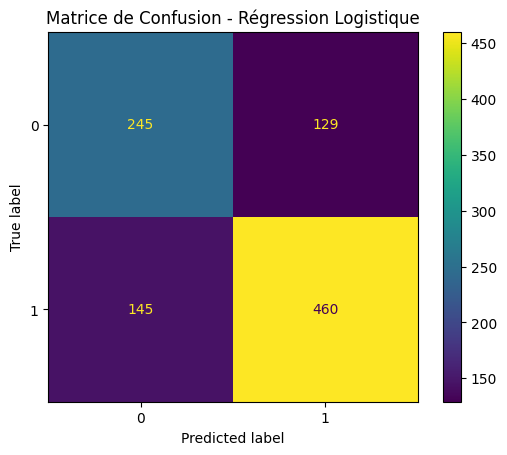

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import time

df = pd.read_csv('missions_fusionnees.csv')
time_cols = [col for col in df.columns if col.startswith('time_')]
features = df.drop(['mission_id', 'is_attack'] + time_cols, axis=1, errors='ignore')

features = features.apply(pd.to_numeric, errors='coerce')

imputer = SimpleImputer(strategy='mean')  # Alternative: 'median' ou 'most_frequent'
features_imputed = imputer.fit_transform(features)

# Vérification des NaN restants
print("Valeurs manquantes après imputation:", np.isnan(features_imputed).sum())

# Split des données
X_train, X_test, y_train, y_test = train_test_split(
    features_imputed, 
    df['is_attack'], 
    test_size=0.3, 
    random_state=42,
    stratify=df['is_attack']
)

# 8. Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

start_time = time.time()  
try:
    lr = LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    )
    lr.fit(X_train_scaled, y_train)
    
    y_pred = lr.predict(X_test_scaled)
    end_time=time.time()
    training_time=end_time - start_time
    print("\n=== Performance du modèle ===")
    print(f"\n⏱ Temps d'entraînement du modèle KNN : {training_time:.2f} secondes")

    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    
    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr.classes_)
    disp.plot()
    plt.title("Matrice de Confusion - Régression Logistique")
    plt.show()

except Exception as e:
    print(f"Erreur lors de l'entraînement: {str(e)}")
    print("\nVérifiez que:")
    print("1. Toutes les colonnes sont numériques")
    print("2. Il n'y a pas de valeurs NaN dans les données")
    print("3. La target ne contient que 0 et 1")

=== SVM ===

⏱ Temps d'entraînement du modèle KNN : 1.09 secondes
              precision    recall  f1-score   support

           0       0.82      0.64      0.72       374
           1       0.81      0.91      0.86       605

    accuracy                           0.81       979
   macro avg       0.81      0.78      0.79       979
weighted avg       0.81      0.81      0.80       979

Accuracy: 0.8100102145045965


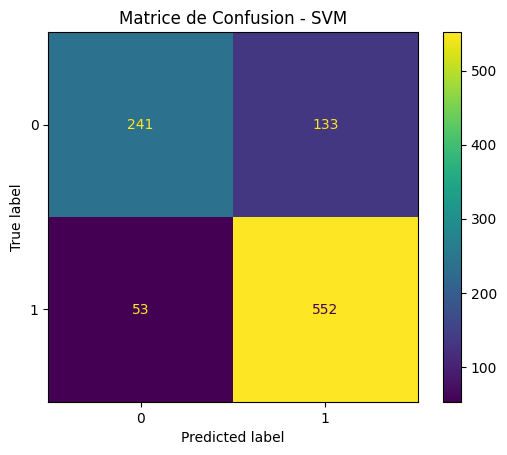

In [ ]:
from sklearn.svm import SVC
import time 
# Modèle SVM
svm = SVC(kernel='rbf', C=1.0)
start_time = time.time()  
svm.fit(X_train_scaled, y_train)
y_pred = svm.predict(X_test_scaled)
end_time = time.time()    
training_time = end_time - start_time


# Évaluation
print("=== SVM ===")
print(f"\n⏱ Temps d'entraînement du modèle SVM : {training_time:.2f} secondes")

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Matrice de Confusion - SVM")
plt.show()


⏱ Temps d'entraînement du modèle SVM : 0.58 secondes

=== SVM ===
              precision    recall  f1-score   support

           0       0.84      0.74      0.79       227
           1       0.87      0.92      0.90       426

    accuracy                           0.86       653
   macro avg       0.85      0.83      0.84       653
weighted avg       0.86      0.86      0.86       653

Accuracy: 0.8591117917304747


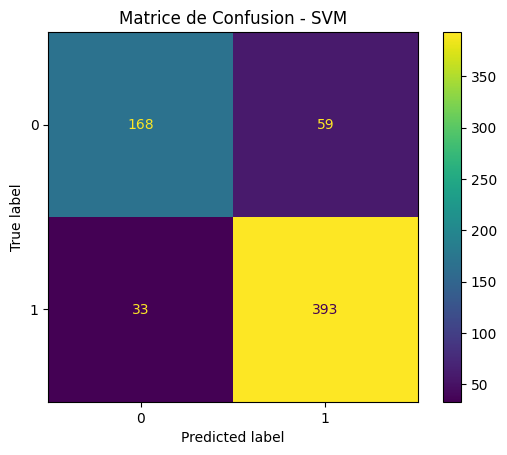

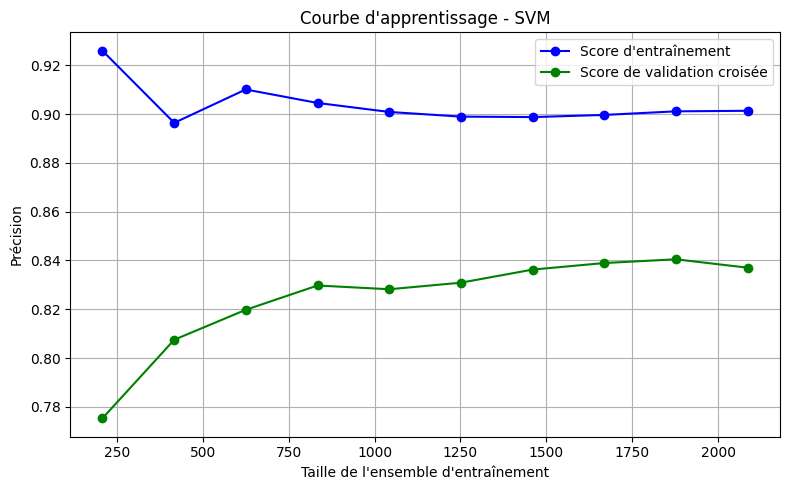

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import time  
df = pd.read_csv("missions_fusionnees.csv")
X = df.drop(columns=["is_attack"])  
y = df["is_attack"]

X = X.fillna(X.mean(numeric_only=True)) 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVC(kernel='rbf', C=1.0)

start_time = time.time()
svm.fit(X_train_scaled, y_train)
end_time = time.time()
training_time = end_time - start_time
print(f"\n⏱ Temps d'entraînement du modèle SVM : {training_time:.2f} secondes")

y_pred = svm.predict(X_test_scaled)
print("\n=== SVM ===")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Matrice de Confusion - SVM")
plt.show()

train_sizes, train_scores, test_scores = learning_curve(
    svm, X_train_scaled, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Score d'entraînement")
plt.plot(train_sizes, test_scores_mean, 'o-', color="green", label="Score de validation croisée")
plt.title("Courbe d'apprentissage - SVM")
plt.xlabel("Taille de l'ensemble d'entraînement")
plt.ylabel("Précision")
plt.legend(loc="best")
plt.grid()
plt.tight_layout()
plt.show()


c:\Users\Amatek\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Meilleurs paramètres: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
Meilleur score (validation): 0.8078

=== Performance du modèle KNN ===
              precision    recall  f1-score   support

           0       0.85      0.56      0.68       125
           1       0.78      0.94      0.85       202

    accuracy                           0.80       327
   macro avg       0.81      0.75      0.76       327
weighted avg       0.81      0.80      0.78       327

Accuracy: 0.7951


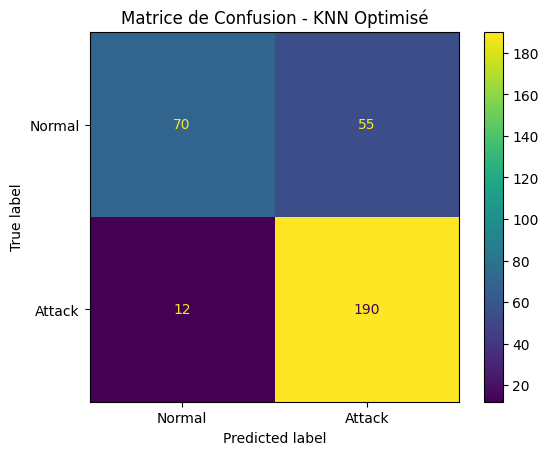


⏱ Temps d'entraînement du modèle KNN : 10.57 secondes


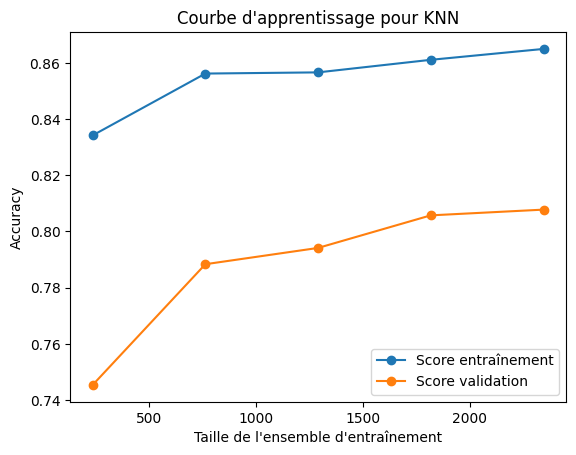

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier  # Import manquant ajouté ici
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import learning_curve







time_cols = [col for col in df.columns if col.startswith('time_')]
features = df.drop(['mission_id', 'is_attack','erreur_m'] + time_cols, axis=1, errors='ignore')
features = features.apply(pd.to_numeric, errors='coerce')

imputer = SimpleImputer(strategy='mean')
features_imputed = imputer.fit_transform(features)

# 5. Split des données
X_train, X_test, y_train, y_test = train_test_split(
    features_imputed, 
    df['is_attack'], 
    test_size=0.1, 
    random_state=42,
    stratify=df['is_attack']
)

# 6. Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Optimisation du KNN
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()
grid = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

start_time = time.time() 
grid.fit(X_train_scaled, y_train)
end_time = time.time()    

training_time = end_time - start_time

best_knn = grid.best_estimator_
print(f"Meilleurs paramètres: {grid.best_params_}")
print(f"Meilleur score (validation): {grid.best_score_:.4f}")

y_pred = best_knn.predict(X_test_scaled)
print("\n=== Performance du modèle KNN ===")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
disp.plot()
plt.title("Matrice de Confusion - KNN Optimisé")
plt.show()


train_sizes, train_scores, test_scores = learning_curve(
    best_knn, X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy')

plt.figure()
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Score entraînement")
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label="Score validation")
plt.title("Courbe d'apprentissage pour KNN")
plt.xlabel("Taille de l'ensemble d'entraînement")
plt.ylabel("Accuracy") 
print(f"\n⏱ Temps d'entraînement du modèle KNN : {training_time:.2f} secondes")

plt.legend()
plt.show()